# Dataset Analysis & Exploratory Data Analysis (EDA)

**Project Title:** Email Intent Classification with Attention-Based Sequence Models and Priority Prediction  
**Dataset Source:** Hugging Face Datasets (`b4b4yg4/email-intent`)  
**Dataset URL:** [https://huggingface.co/datasets/b4b4yg4/email-intent](https://huggingface.co/datasets/b4b4yg4/email-intent)

---

### 🎯 Objective
In this notebook, we perform basic Exploratory Data Analysis (EDA) on the raw `b4b4yg4/email-intent` dataset.
We inspect:
1. Dataset shape & dimensions
2. Column names & data types
3. Sample email rows
4. Missing values & duplicate counts
5. Intent class distribution
6. Urgency/Priority distribution
7. Email text length statistics (characters & words)
8. Visualizations saved to `results/figures/`


In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from huggingface_hub import hf_hub_download

# Set style for plots
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

# Ensure output directory for figures exists
os.makedirs("../results/figures", exist_ok=True)
os.makedirs("../data/raw", exist_ok=True)


## 1. Load Raw Dataset from Hugging Face

In [2]:
repo_id = "b4b4yg4/email-intent"

print("Downloading train.json and test.json from Hugging Face...")
train_path = hf_hub_download(repo_id=repo_id, filename="train.json", repo_type="dataset")
test_path = hf_hub_download(repo_id=repo_id, filename="test.json", repo_type="dataset")

with open(train_path, 'r', encoding='utf-8') as f:
    train_raw = json.load(f)['data']

with open(test_path, 'r', encoding='utf-8') as f:
    test_raw = json.load(f)['data']

def parse_records(items):
    records = []
    for item in items:
        inp = item.get('input', '')
        out = item.get('output', {})
        records.append({
            'email_text': inp,
            'intent': out.get('intent', None),
            'urgency': out.get('urgency', None),
            'order_id': out.get('order_id', None),
            'product': out.get('product', None)
        })
    return pd.DataFrame(records)

train_df = parse_records(train_raw)
test_df = parse_records(test_raw)
df = pd.concat([train_df, test_df], ignore_index=True)

# Save to data/raw CSV files
train_df.to_csv("../data/raw/email_intent_train_raw.csv", index=False)
test_df.to_csv("../data/raw/email_intent_test_raw.csv", index=False)
df.to_csv("../data/raw/email_intent_full_raw.csv", index=False)

print(f"Dataset successfully loaded! Total rows: {len(df)}")


Dataset successfully loaded! Total rows: 2533


## 2. Inspect Dataset Structure & Sample Rows

In [3]:
print(f"Dataset Shape: {df.shape}")
print("\nColumn Data Types:")
print(df.dtypes)
print("\nFirst 10 Rows:")
df.head(10)


Dataset Shape: (2533, 5)

Column Data Types:
email_text    object
intent        object
urgency       object
order_id      object
product       object
dtype: object

First 10 Rows:


,email_text,intent,urgency,order_id,product
0,Subj: Case 0001 - Order 51001 laptop never sho...,delivery_issue,high,51001,laptop
1,"Subj: Case 0002 - Hey, order 51002 (router) sa...",delivery_issue,medium,51002,router
2,Subj: Case 0003 - Order 51003 monitor arrived ...,delivery_issue,high,51003,monitor
3,Subj: Case 0004 - I think you shipped my print...,delivery_issue,medium,51004,printer
4,Subj: Case 0005 - Order 51005 cables are missi...,delivery_issue,medium,51005,cables
5,Subj: Case 0006 - Order 51006 server rack deli...,delivery_issue,high,51006,server rack
6,Subj: Case 0007 - My keyboard from order 51007...,delivery_issue,medium,51007,keyboard
7,Subj: Case 0008 - Order 51008 tablet is stuck ...,delivery_issue,medium,51008,tablet
8,Subj: Case 0009 - Received the wrong item for ...,delivery_issue,high,51009,router
9,Subj: Case 0010 - Order 51010 laptop arrived w...,delivery_issue,medium,51010,laptop


## 3. Missing Values & Duplicate Analysis

In [4]:
print("=== MISSING VALUES PER COLUMN ===")
missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
print(missing_summary)

duplicate_count = df.duplicated(subset=['email_text']).sum()
print(f"\nDuplicate Email Texts Count: {duplicate_count}")


=== MISSING VALUES PER COLUMN ===
            Missing Count  Percentage (%)
email_text              0        0.000000
intent                  0        0.000000
urgency              1533       60.521121
order_id             1385       54.678247
product              1368       54.007106

Duplicate Email Texts Count: 0


## 4. Intent Class Distribution

Number of Unique Intent Classes: 17

Intent Distribution:
intent
multiple_intents              270
availability                  164
complaints                    162
delivery_issue                157
technical_support             148
pricing                       147
credit_and_collections        145
order_modification_request    143
product_docs                  143
invoice_request               142
pricing_and_availability      139
order_status                  138
refund_request                132
out_of_scope                  128
vendor_registration           127
sales_reps                    124
return_request                124
Name: count, dtype: int64


C:\Users\Vivek wadher\AppData\Local\Temp\ipykernel_12340\2913142388.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=intent_counts.values, y=intent_counts.index, palette="viridis")


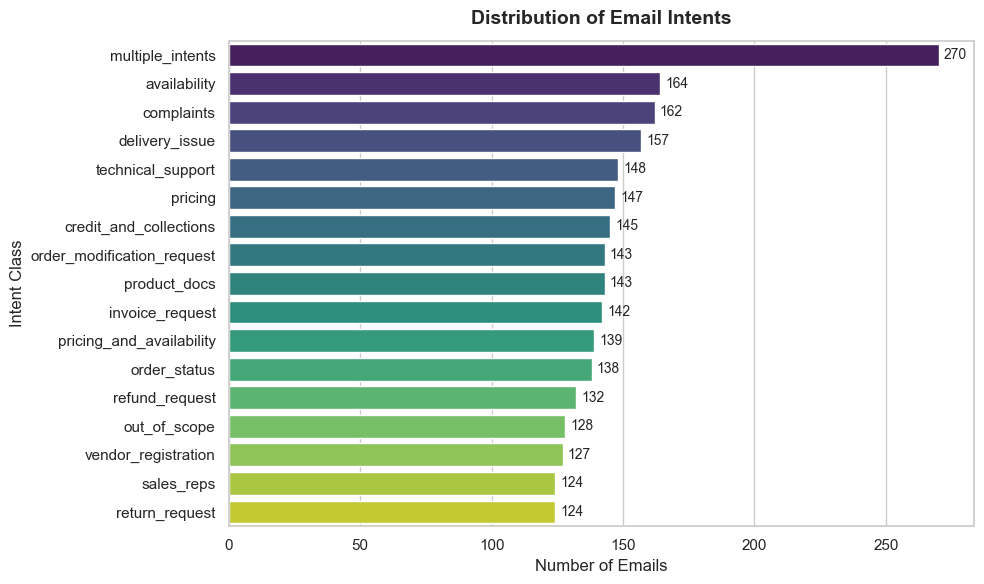

In [5]:
intent_counts = df['intent'].value_counts()
print(f"Number of Unique Intent Classes: {df['intent'].nunique()}")
print("\nIntent Distribution:")
print(intent_counts)

# Plot Intent Distribution
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=intent_counts.values, y=intent_counts.index, palette="viridis")
plt.title("Distribution of Email Intents", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Number of Emails", fontsize=12)
plt.ylabel("Intent Class", fontsize=12)

# Annotate bars with counts
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}',
                (width + 2, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig("../results/figures/intent_distribution.png", dpi=300)
plt.show()


## 5. Urgency / Priority Distribution

Urgency/Priority column present? True

Urgency Distribution (including missing values):
urgency
None      1533
high       403
medium     389
low        208
Name: count, dtype: int64


C:\Users\Vivek wadher\AppData\Local\Temp\ipykernel_12340\2470788434.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=valid_urgency, order=['low', 'medium', 'high'], palette="mako")


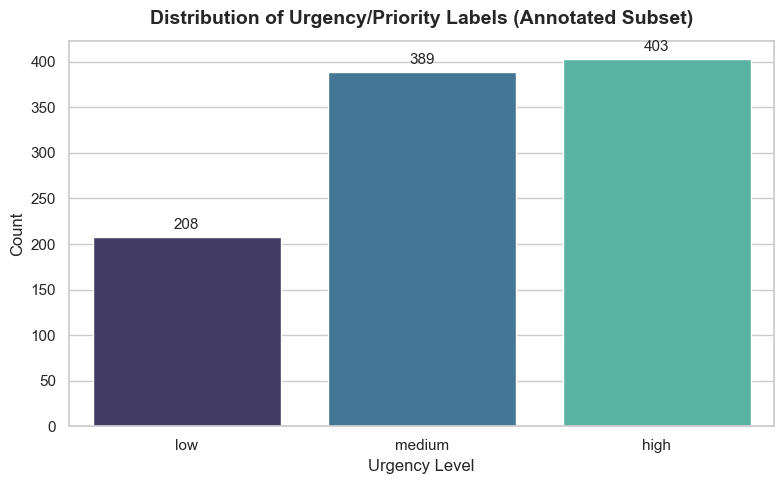

In [6]:
has_urgency = 'urgency' in df.columns
print(f"Urgency/Priority column present? {has_urgency}")

urgency_counts = df['urgency'].value_counts(dropna=False)
print("\nUrgency Distribution (including missing values):")
print(urgency_counts)

# Plot Urgency Distribution for annotated subset
plt.figure(figsize=(8, 5))
valid_urgency = df['urgency'].dropna()
ax = sns.countplot(x=valid_urgency, order=['low', 'medium', 'high'], palette="mako")
plt.title("Distribution of Urgency/Priority Labels (Annotated Subset)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Urgency Level", fontsize=12)
plt.ylabel("Count", fontsize=12)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height + 5),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig("../results/figures/priority_distribution.png", dpi=300)
plt.show()


## 6. Email Text Length Statistics

Character Length Statistics:
count    2533.000000
mean       77.062771
std        18.914343
min        24.000000
25%        64.000000
50%        78.000000
75%        90.000000
max       150.000000
Name: char_length, dtype: float64

Word Count Statistics:
count    2533.000000
mean       13.406632
std         3.645918
min         5.000000
25%        11.000000
50%        13.000000
75%        16.000000
max        28.000000
Name: word_count, dtype: float64


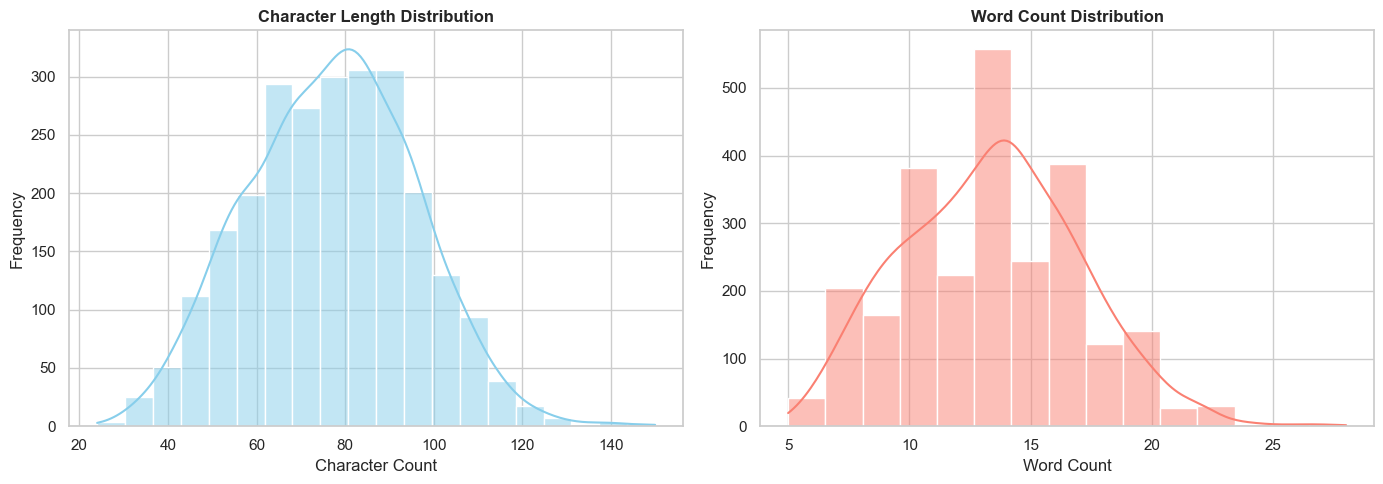

In [7]:
df['char_length'] = df['email_text'].apply(len)
df['word_count'] = df['email_text'].apply(lambda x: len(x.split()))

print("Character Length Statistics:")
print(df['char_length'].describe())

print("\nWord Count Statistics:")
print(df['word_count'].describe())

# Plot Email Length Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['char_length'], kde=True, ax=axes[0], color="skyblue", bins=20)
axes[0].set_title("Character Length Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")

sns.histplot(df['word_count'], kde=True, ax=axes[1], color="salmon", bins=15)
axes[1].set_title("Word Count Distribution", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("../results/figures/email_length_distribution.png", dpi=300)
plt.show()


## 7. Word Cloud of Raw Emails

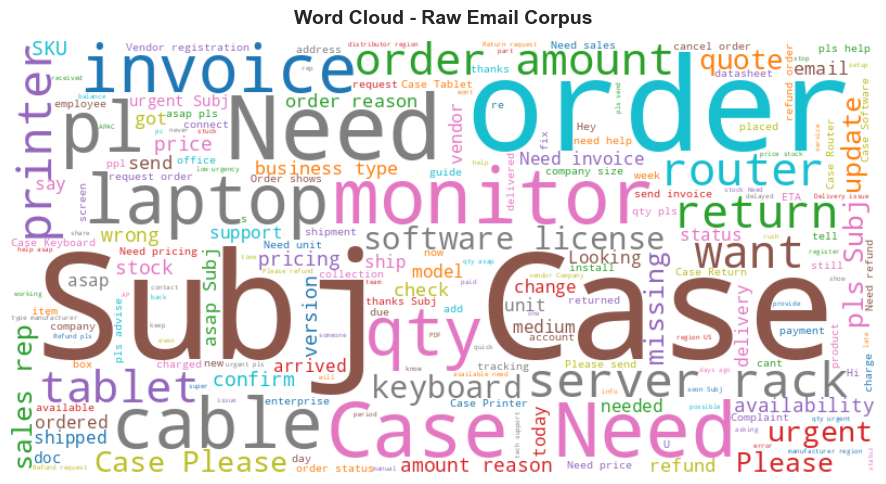

In [8]:
all_text = " ".join(df['email_text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='tab10').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Raw Email Corpus", fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig("../results/figures/wordcloud.png", dpi=300)
plt.show()


## 8. Summary & Observations

- **Total Dataset Size:** 2,533 emails (Train: 2,433, Test: 100)
- **Columns:** `email_text`, `intent`, `urgency`, `order_id`, `product`
- **Intent Classes:** 17 unique intent categories (most frequent: `multiple_intents` with 270, least frequent: `return_request` with 124).
- **Urgency/Priority Column:** Present! Contains 1,000 annotated labels (`high`: 403, `medium`: 389, `low`: 208) and 1,533 missing values.
- **Duplicates & Missing Values:** 0 missing values in `email_text` and `intent`. 0 duplicate email texts.
- **Text Length:** Short concise customer emails with average word count of ~13 words (min: 5, max: 28).
